In [1]:
# Cell 1: Import all required libraries and dependencies
%load_ext autoreload
%autoreload 2
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
import torchdiffeq

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os

# ----------------------------
# Parameters
# ----------------------------
state_steps = 100                  # total number of states (includes initial state)
control_steps = state_steps - 1    # number of control steps to simulate state updates
dt = 0.1                           # time step (seconds)
a_max = 0.25                       # maximum longitudinal acceleration [m/s^2]
delta_max = 0.2                    # maximum steering angle [rad]

# Weights in the cost function
w_p = 10.0      # weight for terminal position error
w_theta = 1.0   # weight for terminal heading error
w_v = 1.0       # weight for terminal speed and yaw rate error (both desired 0)
lambda_reg = 0.1  # regularization for control effort

# ----------------------------
# Configuration for data generation
# ----------------------------
num_trajectories = 1000
save_filename = 'Car_trajectories_dataset.npy'
LOAD_SAVED_DATA = False 
progress_step = max(num_trajectories // 10, 1)

# ----------------------------
# Utility Functions
# ----------------------------
def sample_point_in_circle(center, radius):
    """
    Sample a random point inside a circle with specified center and radius.
    """
    angle = np.random.uniform(0, 2*np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def simulate_vehicle(x0, u_seq, dt=0.1):
    """
    Simulate the vehicle dynamics.
    
    x0: initial state [x, y, theta, v, r]
    u_seq: control sequence of shape (control_steps, 2), for each step: [a, delta]
    
    The vehicle dynamics (using Euler discretization):
      x_{k+1} = x_k + dt * v_k * cos(theta_k)
      y_{k+1} = y_k + dt * v_k * sin(theta_k)
      theta_{k+1} = theta_k + dt * r_k
      v_{k+1} = v_k + dt * a_k
      r_{k+1} = r_k + dt * delta_k
      
    Returns:
      states: NumPy array of shape (state_steps, 5)
    """
    states = np.zeros((state_steps, 5))
    states[0] = x0
    # For k=0,...,control_steps-1, apply optimized control
    for k in range(control_steps):
        x, y, theta, v, r = states[k]
        a, delta = u_seq[k]
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = v + dt * a
        r_next = r + dt * delta
        states[k+1] = [x_next, y_next, theta_next, v_next, r_next]
    return states


def cost_function(u_flat, x0, target, dt, control_steps, 
                  lambda_reg=lambda_reg, w_p=w_p, w_theta=w_theta, w_v=w_v):
    """
    Cost function for optimal control.
    
    The cost includes:
      1. Terminal state error: 
         - Position error: ||[x_N, y_N] - target||^2 
         - Heading error: (theta_N - 0)^2 (target heading fixed at 0 rad)
         - Speed error: (v_N - 0)^2
         - Yaw rate error: (r_N - 0)^2
      2. Control effort penalty: lambda_reg * sum(a_k^2 + delta_k^2) over all steps
    """
    u_seq = u_flat.reshape((control_steps, 2))
    states = simulate_vehicle(x0, u_seq, dt)
    final_state = states[-1]
    pos_error = np.linalg.norm(final_state[:2] - target)**2
    theta_error = (final_state[2] - 0)**2   # desired heading 0 rad
    v_error = (final_state[3] - 0)**2         # desired speed 0
    r_error = (final_state[4] - 0)**2         # desired yaw rate 0
    control_penalty = lambda_reg * np.sum(u_seq**2)
    J = w_p * pos_error + w_theta * theta_error + w_v * (v_error + r_error) + control_penalty
    return J

# ----------------------------
# Optimization Bounds and Setup
# ----------------------------
# Since we optimize for control_steps steps, total decision variables: control_steps * 2
bounds = []
for _ in range(control_steps):
    bounds.append((-a_max, a_max))       # for a_k
    bounds.append((-delta_max, delta_max)) # for delta_k

# ----------------------------
# Data Generation or Loading
# ----------------------------
# if LOAD_SAVED_DATA and os.path.exists(save_filename):
#     print("Loading trajectories dataset from file:", save_filename)
#     trajectories = np.load(save_filename, allow_pickle=True)
# else:
#     trajectories = []
#     print("Generating trajectories...")
#     for i in range(num_trajectories):
#         # Sample start and target positions from defined circles:
#         start = sample_point_in_circle(np.array([-1, -1]), 0.2)
#         target = sample_point_in_circle(np.array([1, 1]), 0.2)
    
#         # Fixed initial state: heading = 0, speed = 0, yaw rate = 0.
#         x0 = np.array([start[0], start[1], 0.0, 0.0, 0.0])
    
#         # Initial guess for control sequence: zeros (length = control_steps * 2)
#         u0 = np.zeros(control_steps * 2)
    
#         # Solve the optimal control problem using SciPy's SLSQP
#         res = minimize(cost_function, u0, args=(x0, target, dt, control_steps),
#                        method='SLSQP', bounds=bounds,
#                        options={'maxiter': 1000, 'ftol': 1e-6, 'disp': False})
    
#         # Reshape optimized control sequence to (control_steps, 2)
#         u_opt = res.x.reshape((control_steps, 2))
#         # Pad the final control with [0,0] so that controls have shape (state_steps,2)
#         controls_padded = np.vstack([u_opt, [0, 0]])
    
#         states = simulate_vehicle(x0, u_opt, dt)
    
#         trajectories.append({'states': states, 'controls': controls_padded, 
#                              'start': start, 'target': target})

#         if (i + 1) % progress_step == 0:
#             percent_done = ((i + 1) / num_trajectories) * 100
#             print(f"{percent_done:.0f}% of trajectories generated ({i + 1}/{num_trajectories})")
#             np.save(save_filename, trajectories, allow_pickle=True)
#     np.save(save_filename, trajectories, allow_pickle=True)
#     print("Trajectories generation completed and saved to", save_filename)

# # ----------------------------
# # Visualization
# # ----------------------------
# idx = np.random.choice(len(trajectories))
# traj = trajectories[idx]
# states = traj['states']
# u_seq = traj['controls']

# time_states = np.linspace(0, (state_steps-1)*dt, state_steps)
# time_controls = np.linspace(0, (state_steps-1)*dt, state_steps)

# plt.figure(figsize=(8,6))
# plt.plot(states[:,0], states[:,1], marker='o', linestyle='-', label='Trajectory')
# plt.scatter(traj['start'][0], traj['start'][1], color='green', label='Start')
# plt.scatter(traj['target'][0], traj['target'][1], color='red', label='Target')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.title('2D Position Trajectory')
# plt.legend()
# plt.axis('equal')
# plt.grid(True)
# plt.show()

# fig, axs = plt.subplots(2, 1, figsize=(10,8), sharex=True)
# axs[0].plot(time_controls, u_seq[:,0], marker='o', linestyle='-')
# axs[0].set_ylabel('Acceleration [m/s$^2$]')
# axs[0].set_title('Longitudinal Acceleration')
# axs[1].plot(time_controls, u_seq[:,1], marker='o', linestyle='-')
# axs[1].set_xlabel('Time [s]')
# axs[1].set_ylabel('Steering Angle [rad]')
# axs[1].set_title('Steering Angle')
# plt.tight_layout()
# plt.show()


In [3]:
# Load from store
# ==== Cell 0: Load saved trajectories ====
import os
import numpy as np

filename = 'Car_trajectories_dataset.npy'
assert os.path.exists(filename), f"{filename} not found!"

trajectories = np.load(filename, allow_pickle=True)

print(f"Loaded {len(trajectories)} trajectories from '{filename}'")
print("Example traj keys:", trajectories[0].keys())
print("states.shape =", trajectories[0]['states'].shape,
      "controls.shape =", trajectories[0]['controls'].shape)
from torch.utils.data import Dataset, DataLoader
import torch
batch_size=64
traj_arr = np.stack([
    np.concatenate([traj['states'][:, :3].T,
                    traj['controls'][:100].T], axis=0)
    for traj in trajectories
], axis=0).astype(np.float32)  # shape (N,5,100)

class TrajectoryDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx])  # FloatTensor

train_loader = DataLoader(
    TrajectoryDataset(traj_arr),
    batch_size=batch_size, shuffle=True, num_workers=0
)

print("Train loader ready, #batches =", len(train_loader))


AssertionError: Car_trajectories_dataset.npy not found!

In [4]:
# ----------------------------
# Post-processing: filter inconsistent trajectories
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt

pos_error_threshold = 1e-2  

#trajectories = np.load(save_filename, allow_pickle=True)

filtered = []
removed_count = 0

for idx, traj in enumerate(trajectories):
    states_orig = traj['states']      
    controls   = traj['controls'][:-1] 

    states_sim = simulate_vehicle(states_orig[0], controls, dt=dt)
    pos_diff = states_orig[:, :2] - states_sim[:, :2]
    max_pos_err = np.max(np.linalg.norm(pos_diff, axis=1))

    if max_pos_err > pos_error_threshold:
        removed_count += 1
        print(f"Trajectory {idx} removed: max position error = {max_pos_err:.4f} m")

        plt.figure(figsize=(6,5))
        plt.plot(states_orig[:,0], states_orig[:,1], 'b-o', label='Original')
        plt.plot(states_sim[:,0], states_sim[:,1], 'C1--s', label='Re-simulated')
        plt.title(f'Traj {idx} deviation (err={max_pos_err:.4f} m)')
        plt.xlabel('X [m]')
        plt.ylabel('Y [m]')
        plt.legend()
        plt.axis('equal')
        plt.grid(True)
        plt.show()
    else:
        filtered.append(traj)

print(f"\nFiltering complete: {removed_count} trajectories removed, {len(filtered)} remain.")

filtered_filename = 'Car_trajectories_dataset_filtered.npy'
np.save(filtered_filename, filtered, allow_pickle=True)
print("Filtered dataset saved to", filtered_filename)



Filtering complete: 0 trajectories removed, 1000 remain.
Filtered dataset saved to Car_trajectories_dataset_filtered.npy


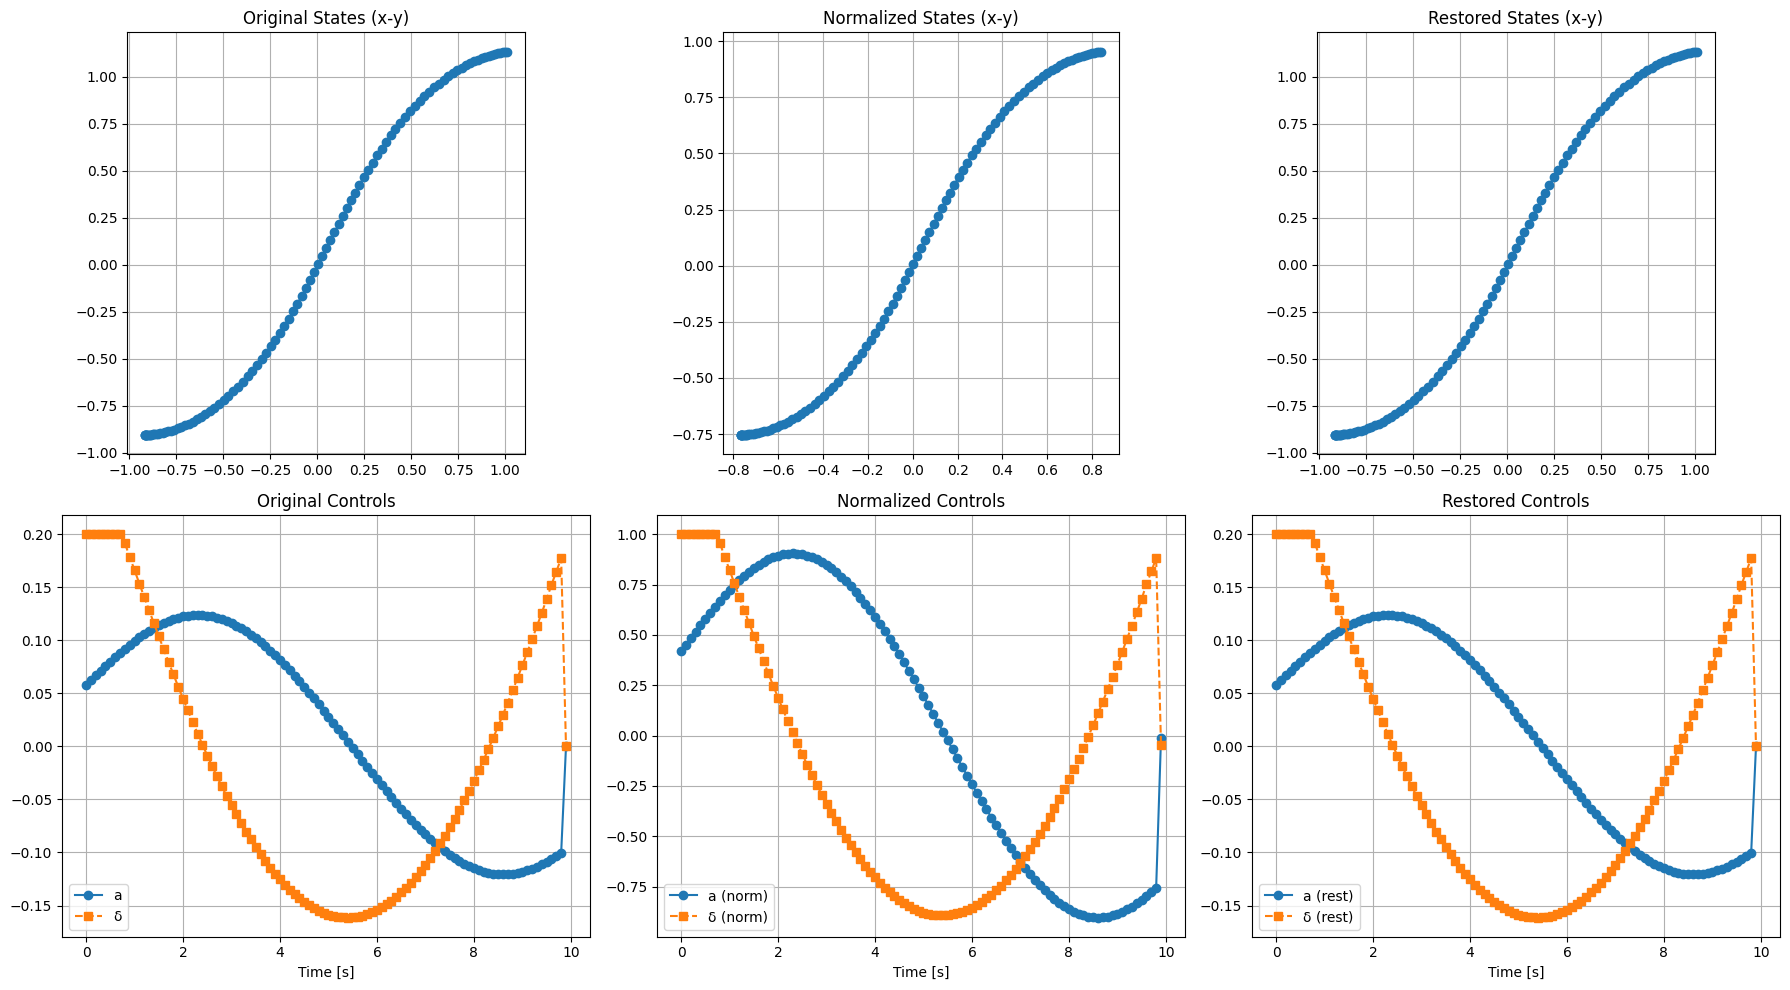

In [5]:
import numpy as np
import matplotlib.pyplot as plt

class Scaler:
    def __init__(self, data_min, data_max):

        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):

        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):

        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

try:
    trajectories
except NameError:
    trajectories = np.load('Car_trajectories_dataset.npy', allow_pickle=True)

all_states   = np.vstack([traj['states']   for traj in trajectories])  # (num_traj*state_steps, 5)
all_controls = np.vstack([traj['controls'] for traj in trajectories])  # (num_traj*state_steps, 2)

state_min,   state_max   = all_states.min(axis=0),   all_states.max(axis=0)
control_min, control_max = all_controls.min(axis=0), all_controls.max(axis=0)

state_scaler   = Scaler(state_min,   state_max)
control_scaler = Scaler(control_min, control_max)

idx = np.random.randint(len(trajectories))
sample = trajectories[idx]
orig_states   = sample['states']    # shape=(state_steps, 5)
orig_controls = sample['controls']  # shape=(state_steps, 2)

norm_states   = state_scaler.normalize(orig_states)
rest_states   = state_scaler.denormalize(norm_states)

norm_controls = control_scaler.normalize(orig_controls)
rest_controls = control_scaler.denormalize(norm_controls)

dt = 0.1
time_ctrl = np.arange(orig_controls.shape[0]) * dt

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

axs[0, 0].plot(orig_states[:,0],   orig_states[:,1],   'o-')
axs[0, 0].set_title('Original States (x-y)')
axs[0, 0].set_aspect('equal', 'box')
axs[0, 0].grid(True)

axs[0, 1].plot(norm_states[:,0],   norm_states[:,1],   'o-')
axs[0, 1].set_title('Normalized States (x-y)')
axs[0, 1].set_aspect('equal', 'box')
axs[0, 1].grid(True)

axs[0, 2].plot(rest_states[:,0],   rest_states[:,1],   'o-')
axs[0, 2].set_title('Restored States (x-y)')
axs[0, 2].set_aspect('equal', 'box')
axs[0, 2].grid(True)

axs[1, 0].plot(time_ctrl, orig_controls[:,0], 'o-', label='a')
axs[1, 0].plot(time_ctrl, orig_controls[:,1], 's--', label='δ')
axs[1, 0].set_title('Original Controls')
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].plot(time_ctrl, norm_controls[:,0], 'o-', label='a (norm)')
axs[1, 1].plot(time_ctrl, norm_controls[:,1], 's--', label='δ (norm)')
axs[1, 1].set_title('Normalized Controls')
axs[1, 1].set_xlabel('Time [s]')
axs[1, 1].legend()
axs[1, 1].grid(True)

axs[1, 2].plot(time_ctrl, rest_controls[:,0], 'o-', label='a (rest)')
axs[1, 2].plot(time_ctrl, rest_controls[:,1], 's--', label='δ (rest)')
axs[1, 2].set_title('Restored Controls')
axs[1, 2].set_xlabel('Time [s]')
axs[1, 2].legend()
axs[1, 2].grid(True)

plt.tight_layout()
plt.show()


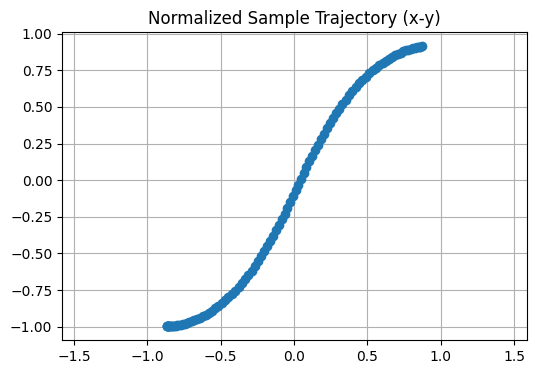

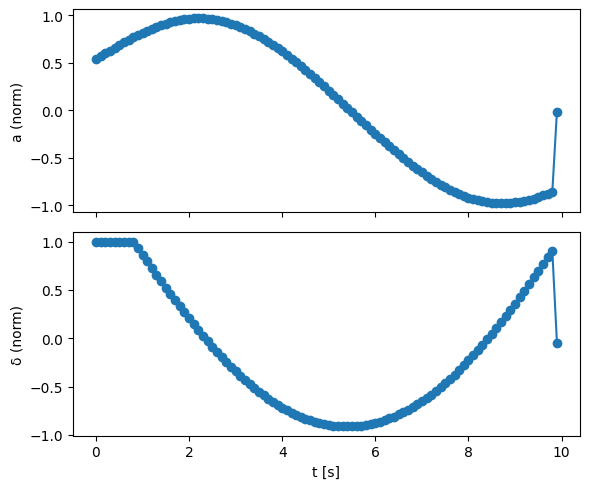

[Grad Monitor] Epoch 450/4500, Max Grad = 0.144640
Epoch 450/4500  |  avg loss = 0.208289
[Checkpoint] Epoch 500/4500  |  avg loss = 0.152310
[Grad Monitor] Epoch 900/4500, Max Grad = 0.220058
Epoch 900/4500  |  avg loss = 0.095607
[Checkpoint] Epoch 1000/4500  |  avg loss = 0.079223
[Grad Monitor] Epoch 1350/4500, Max Grad = 0.069885
Epoch 1350/4500  |  avg loss = 0.081235
[Checkpoint] Epoch 1500/4500  |  avg loss = 0.067226
[Grad Monitor] Epoch 1800/4500, Max Grad = 0.105798
Epoch 1800/4500  |  avg loss = 0.067468
[Checkpoint] Epoch 2000/4500  |  avg loss = 0.059906
[Grad Monitor] Epoch 2250/4500, Max Grad = 0.043544
Epoch 2250/4500  |  avg loss = 0.051880
[Checkpoint] Epoch 2500/4500  |  avg loss = 0.053551
[Grad Monitor] Epoch 2700/4500, Max Grad = 0.050421
Epoch 2700/4500  |  avg loss = 0.045741
[Checkpoint] Epoch 3000/4500  |  avg loss = 0.041457
[Grad Monitor] Epoch 3150/4500, Max Grad = 0.051508
Epoch 3150/4500  |  avg loss = 0.043788
[Checkpoint] Epoch 3500/4500  |  avg loss =

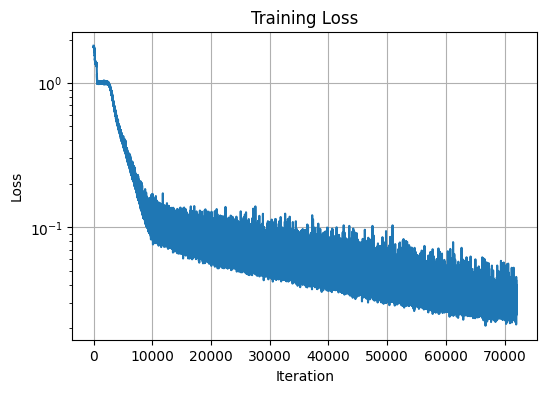

Training completed!


In [6]:
# ==== 0. Imports & Setup ====
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

# ==== 1. Constants ====
dt = 0.1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 64
n_epochs = 4500
#n_epochs=1
lr = 1e-4
warmup_epochs = int(0.1 * n_epochs)
report_interval = max(1, n_epochs // 10)

# ==== 2. Compute min/max only on used dims & init scalers ====
all_states_s = np.vstack([traj['states'][:, :3]     for traj in trajectories])  # shape (N*100, 3)
all_controls = np.vstack([traj['controls'][:100]    for traj in trajectories])  # shape (N*100, 2)

state_min, state_max   = all_states_s.min(axis=0),   all_states_s.max(axis=0)   # (3,), (3,)
ctrl_min,  ctrl_max    = all_controls.min(axis=0),   all_controls.max(axis=0)    # (2,), (2,)

state_scaler   = Scaler(state_min, state_max)
control_scaler = Scaler(ctrl_min,  ctrl_max)

# ==== 3. Dataset & DataLoader (保持不变) ====
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories, state_scaler, control_scaler):
        self.trajs = trajectories
        self.state_s = state_scaler
        self.ctrl_s = control_scaler

    def __len__(self):
        return len(self.trajs)

    def __getitem__(self, idx):
        traj = self.trajs[idx]
        s = traj['states'][:, :3]     # (100,3)
        c = traj['controls'][:100]    # (100,2)
        s_norm = self.state_s.normalize(s)
        c_norm = self.ctrl_s.normalize(c)
        sample = np.concatenate([s_norm.T, c_norm.T], axis=0).astype(np.float32)  # (5,100)
        return torch.from_numpy(sample)

train_loader = DataLoader(
    TrajectoryDataset(trajectories, state_scaler, control_scaler),
    batch_size=batch_size, shuffle=True, num_workers=0
)



# ==== 4. 可视化 (保持不变) ====
batch = next(iter(train_loader))    # shape (B,5,100)
sample = batch[0].numpy()
x_n, y_n, theta_n, a_n, delta_n = sample
t_axis = np.linspace(0, (sample.shape[1]-1)*dt, sample.shape[1])

plt.figure(figsize=(6,4))
plt.plot(x_n, y_n, '-o')
plt.title("Normalized Sample Trajectory (x-y)")
plt.axis('equal'); plt.grid(True)
plt.show()

fig, axs = plt.subplots(2,1,figsize=(6,5), sharex=True)
axs[0].plot(t_axis, a_n, '-o');    axs[0].set_ylabel('a (norm)')
axs[1].plot(t_axis, delta_n, '-o'); axs[1].set_ylabel('δ (norm)'); axs[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

# ==== 5. 模型组件 (保持不变) ====
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class ResidualFC(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = Mish()
    
    def forward(self, x):
        out = self.act(self.fc1(x))
        out = self.fc2(out)
        return self.act(out + x)

class UpSampler(nn.Module):
    def __init__(self, in_shape=(5,100), out_shape=(1,28,28), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        x = self.norm(x)
        return x.view(x.size(0), *self.out_shape)

class DownSampler(nn.Module):
    def __init__(self, in_shape=(1,28,28), out_shape=(5,100), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        return x.view(x.size(0), *self.out_shape)

class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        hidden = max(channels // ratio, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False), Mish(),
            nn.Conv2d(hidden, channels, 1, bias=False), nn.Sigmoid()
        )
    
    def forward(self, x):
        att = self.fc(self.avg(x) + self.max(x))
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=k, padding=k//2, bias=False)
    
    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        mx, _ = x.max(1, keepdim=True)
        att = torch.sigmoid(self.conv(torch.cat([avg, mx], 1)))
        return x * att

class UNetWithAttention(UNetModel):
    def __init__(self, dim, num_channels, num_res_blocks, num_classes, class_cond):
        super().__init__(
            image_size=dim[-1],
            in_channels=dim[0],
            model_channels=num_channels,
            out_channels=dim[0],
            num_res_blocks=num_res_blocks,
            attention_resolutions=(16,),
            channel_mult=(1, 2, 2),
            num_classes=num_classes if class_cond else None
        )
        in_ch = dim[0]
        self.ca = ChannelAttention(in_ch)
        self.sa = SpatialAttention()
    
    def forward(self, t, x, y=None):
        feat = super().forward(t, x, y)
        feat = self.ca(feat)
        feat = self.sa(feat)
        return feat

# ==== 6. 创建fmtorch兼容的流模型 ====
class CarTrajectoryFlowModel(ModelWrapper):
    def __init__(self, upsampler, unet_model, downsampler):
        nn.Module.__init__(self)  # 直接初始化nn.Module
        self.upsampler = upsampler
        self.unet = unet_model
        self.downsampler = downsampler
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        # x shape: (batch_size, 5, 100)
        # t shape: (batch_size,)
        
        # 上采样到图像空间
        x_img = self.upsampler(x)  # (batch_size, 1, 28, 28)
        
        # 为UNet准备dummy标签
        batch_size = x.shape[0]
        dummy_label = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        
        # 通过UNet
        v_img = self.unet(t, x_img, dummy_label)
        
        # 下采样回轨迹空间
        v_traj = self.downsampler(v_img)  # (batch_size, 5, 100)
        
        return v_traj

# ==== 7. 初始化模型和优化器 ====
upsampler = UpSampler().to(device)
downsampler = DownSampler().to(device)
unet = UNetWithAttention(
    dim=(1, 28, 28), 
    num_channels=32, 
    num_res_blocks=2,
    num_classes=10, 
    class_cond=True
).to(device)

# 创建fmtorch流模型
flow_model = CarTrajectoryFlowModel(upsampler, unet, downsampler)

# 优化器
optim = torch.optim.Adam(
    list(upsampler.parameters()) +
    list(downsampler.parameters()) +
    list(unet.parameters()), 
    lr=lr
)

# 学习率调度器
scheduler = LambdaLR(
    optim, lr_lambda=lambda epoch: (
        float(epoch) / warmup_epochs if epoch < warmup_epochs else
        0.5*(1.0 + math.cos(math.pi*(epoch - warmup_epochs)/(n_epochs - warmup_epochs)))
    )
)

# ==== 初始化fmtorch组件 ====
path = AffinePath(scheduler=CondOTScheduler())

# # ==== 8. 使用fmtorch的训练循环 ====
best_loss = float('inf')
loss_history = []

for epoch in range(1, n_epochs+1):
    epoch_loss = 0.0
    batch_count = 0
    monitor_grad = (epoch % report_interval == 0)

    for batch_idx, batch in enumerate(train_loader):
        x1 = batch.to(device)  # 目标轨迹
        x0 = torch.randn_like(x1)  # 噪声初始化
        
        # 使用fmtorch的路径采样
        t = torch.rand(x1.shape[0]).to(device)
        path_sample = path.sample(t=t, x_0=x0, x_1=x1)
        
        # 通过流模型预测速度
        vt_pred = flow_model(path_sample.x_t, path_sample.t)
        
        # 计算损失
        # 1. Flow matching损失
        flow_loss = F.mse_loss(vt_pred, path_sample.dx_t)
        
        # 2. 重建损失
        x1_recon = flow_model.downsampler(flow_model.upsampler(x1))
        recon_loss = F.mse_loss(x1_recon, x1)
        
        # 总损失
        loss = flow_loss + recon_loss

        optim.zero_grad()
        loss.backward()

        # 梯度监控
        if monitor_grad and batch_idx == 0:
            max_grad = max(
                p.grad.abs().max().item()
                for g in optim.param_groups for p in g['params']
                if p.grad is not None
            )
            print(f"[Grad Monitor] Epoch {epoch}/{n_epochs}, Max Grad = {max_grad:.6f}")

        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(
            list(upsampler.parameters()) +
            list(downsampler.parameters()) +
            list(unet.parameters()), 
            max_norm=1.0
        )
        optim.step()

        loss_history.append(loss.item())
        epoch_loss += loss.item()
        batch_count += 1

    # 更新学习率
    scheduler.step()

    # 计算平均损失
    epoch_loss /= batch_count

    # 常规日志
    if epoch % report_interval == 0:
        print(f"Epoch {epoch}/{n_epochs}  |  avg loss = {epoch_loss:.6f}")
    if epoch % 500 == 0:
        print(f"[Checkpoint] Epoch {epoch}/{n_epochs}  |  avg loss = {epoch_loss:.6f}")

    # 从epoch 3500开始，每200个epoch保存最佳模型
    if epoch >= 3500 and epoch % 200 == 0:
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            ckpt = {
                'epoch': epoch,
                'upsampler': upsampler.state_dict(),
                'downsampler': downsampler.state_dict(),
                'unet': unet.state_dict(),
                'optimizer': optim.state_dict(),
                'loss': best_loss
            }
            torch.save(ckpt, f'fmtorch_best_ckpt_epoch{epoch:04d}.pt')
            print(f"→ Saved new best checkpoint at epoch {epoch}, loss {best_loss:.6f}")
        else:
            print(f"→ Epoch {epoch}, loss {epoch_loss:.6f} did not improve (best {best_loss:.6f})")

# ==== 9. 绘制损失曲线 ====
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.yscale('log')
plt.grid(True)
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

print("Training completed!")

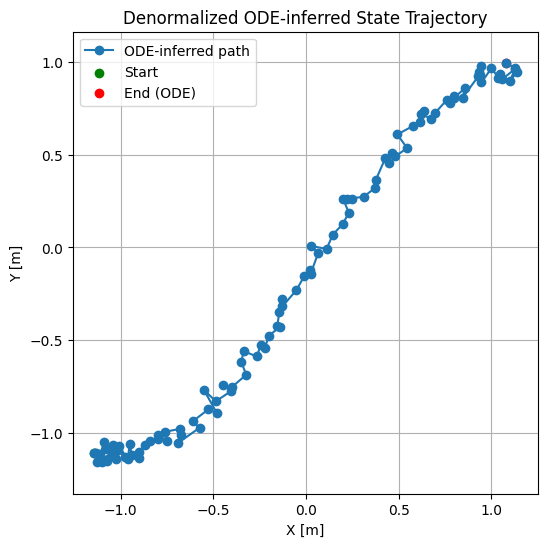

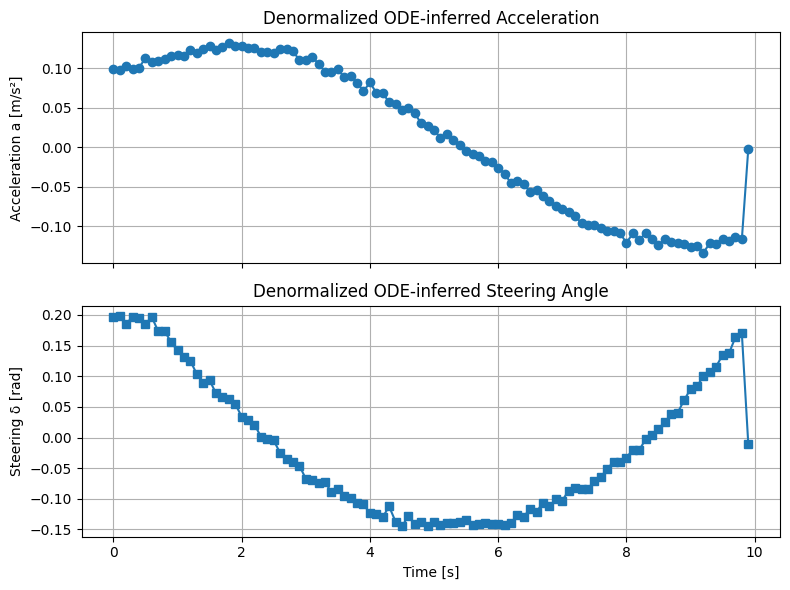

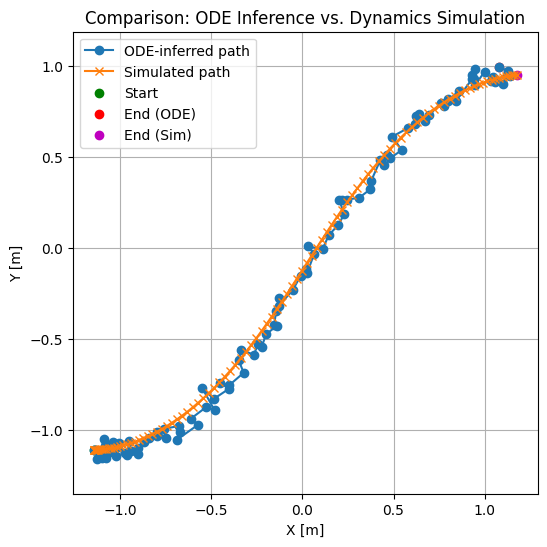

In [ ]:
# ==== Cell: Load checkpoint, ODE inference, denormalize & compare ====

import torch
import torchdiffeq
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load('fmtorch_best_ckpt_epoch4400.pt', map_location=device)
upsampler.load_state_dict(ckpt['upsampler'])
downsampler.load_state_dict(ckpt['downsampler'])
unet.load_state_dict(ckpt['unet'])
upsampler.eval()
downsampler.eval()
unet.eval()

# 2. Perform ODE-based flow-matching inference (in normalized space)
with torch.no_grad():
    x0_noise = torch.randn((1, 5, state_steps), device=device)
    t_span = torch.linspace(0., 1., 2, device=device)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 5, state_steps)
        img = upsampler(x)
        labels = torch.zeros((1,), dtype=torch.long, device=device)
        v_img = unet(t, img, labels)
        v_traj = downsampler(v_img)
        return v_traj.view(-1)

    traj_t = torchdiffeq.odeint(
        fm_ode_func,
        x0_noise.view(-1),
        t_span,
        atol=1e-5,
        rtol=1e-5,
        method='dopri5'
    )
    x_fm_norm = traj_t[-1].view(5, state_steps).cpu().numpy()  # shape: (5, 100)

# 3. Split into states and controls, then denormalize
states_norm   = x_fm_norm[:3, :].T   # (100, 3): [x, y, theta]
controls_norm = x_fm_norm[3:5, :].T  # (100, 2): [accel, steer]

states   = state_scaler.denormalize(states_norm)      # (100, 3)
controls = control_scaler.denormalize(controls_norm)  # (100, 2)

# 4. Visualize the inferred state trajectory and control sequence
time = np.linspace(0, (state_steps-1)*dt, state_steps)

plt.figure(figsize=(6,6))
plt.plot(states[:,0], states[:,1], '-o', label='ODE-inferred path')
plt.scatter(states[0,0], states[0,1], c='g', label='Start')
plt.scatter(states[-1,0], states[-1,1], c='r', label='End (ODE)')
plt.title('Denormalized ODE-inferred State Trajectory')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True)
ax1.plot(time, controls[:,0], '-o')
ax1.set_ylabel('Acceleration a [m/s²]')
ax1.set_title('Denormalized ODE-inferred Acceleration')
ax1.grid(True)

ax2.plot(time, controls[:,1], '-s')
ax2.set_ylabel('Steering δ [rad]')
ax2.set_xlabel('Time [s]')
ax2.set_title('Denormalized ODE-inferred Steering Angle')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Simulate vehicle dynamics with the inferred controls and compare
x0_state = np.concatenate([states[0], [0.0, 0.0]])  # [x0, y0, theta0, v0=0, r0=0]
sim_states = simulate_vehicle(x0=x0_state, u_seq=controls[:control_steps], dt=dt)

plt.figure(figsize=(6,6))
plt.plot(states[:,0],     states[:,1],     '-o', label='ODE-inferred path')
plt.plot(sim_states[:,0], sim_states[:,1], '-x', label='Simulated path')
plt.scatter(states[0,0], states[0,1], c='g', label='Start')
plt.scatter(states[-1,0], states[-1,1], c='r', label='End (ODE)')
plt.scatter(sim_states[-1,0], sim_states[-1,1], c='m', label='End (Sim)')
plt.title('Comparison: ODE Inference vs. Dynamics Simulation')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()
